**Name:** \_\_HAN Zhuo\_\_

**EID:** \_\_zhuohan3\_\_

# CS5489 - Assignment 1 - SMS classification

## Goal
In this assignment, the task is predict whether an SMS message is a real message, a spam message, or a phishing message (called smishing). Here are some examples:

  - **Normal**: "For real tho this sucks. I can't even cook my whole electricity is out. And I'm hungry."
  - **Spam**: "Had your mobile 10 mths? Update to latest Orange camera/video phones for FREE. Save £s with Free texts/weekend calls. Text YES for a callback orno to opt out"
  - **Smishing**: "Todays Vodafone numbers ending 5347 are selected to receive a Rs.2,00,000 award. If you have a match please call 6299257179 quoting claim code 2041 standard rates apply"


Your goal is to train a classifier to predict the class from the SMS text.


## Methodology
You need to train classifiers using the training data, and then predict on the test data. You are free to choose the feature extraction method and classifier algorithm.  You are free to use methods that were not introduced in class.  You should probably do cross-validation to select a good parameters.


## Evaluation

You need to report your test predictions. The csv file has determined the split of validation and test data, where the validation data will be used to determine the timestep of checkpointing. The model that achieves the best performance on validation set should be used to evaluate the test data. The test performance will be used to calculate your final ranking.

The evaluation metric is **balanced accuracy score**. This is because the dataset has some class imbalance as there are more normal samples than spam/smishing samples. See details for `sklearn.metrics.balanced_accuracy_score` [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html).

## What to hand in
You need to turn in the following things:

1. This ipynb file `Assignment1-Doc.ipynb` with your source code and documentation. _**You should write about all the various attempts that you make to find a good solution.**_ You may also submit python scripts as source code, but you then must document all analysis and results (figures, outputs, etc.) in the ipynb file.
2. The PDF file exported from your `Assignment1-Doc.ipynb` file.
3. Your final CSV submission file on test data.
4. The ipynb file `Assignment1-Final.ipynb`, which contains the code that generates the final CSV submission file.  **This code will be used to verify that your submission is reproducible.**

**Please compress all four files into a single zipfile and upload it to Assignment 1 on Canvas.**

## Basic Requirements of Documentation:

For your documentation, you need to at least explain the following things:

- **Data Preprocessing**: This section should detail your exploratory data analysis and the rationale behind all preprocessing steps.
  - Describe the initial characteristics of your dataset.
  - Explain all techniques you have applied on the data
  - Clearly state which subset of the data was used to determine any inherent hyperparameters within your preprocessing techniques, ensuring no information from the test set was used (if any)
- **Methodology**: you will justify your modeling choices.
  - Chosen Models: describe the core principle or model architecture (for deep learning)
  - Chosen Optimizers (if any)
  - Chosen Loss Function (if any)
- **Hyperparameters**: This section should demonstrate a rigorous approach to hyper-parameter selection
  - List the key hyperparameters used
  - Document your hyperparameter search process. Compare model performance on a dedicated validation set and select the best-performing configuration based solely on validation metrics. As a core principle of this course, using the test set for hyperparameter selection is strictly prohibited and constitutes academic dishonesty.
- **Results and Visualization**: This section should provide clear evidence of your model's performance and a qualitative analysis of its behavior.
  - Learning Curves (only for deep learning methods): the loss (error) and/or accuracy on training and validation set must be provided.
  - Show examples of correctly classified and misclassified test samples. For misclassified samples, hypothesize why the model failed.

## Grading
The marks of the assignment are distributed as follows:
- 45% - Results using various classifiers and feature representations.
- 30% - Trying out feature representations (e.g. adding additional features) or classifiers not used in the tutorials/lectures.
- 20% - Quality of the written report.  More points for insightful observations and analysis.
- 5% - Final performance on the test data. If a submission cannot be reproduced by the submitted code, it will not receive marks for ranking.
- **Late Penalty:** 25 marks will be subtracted for each day late.

**NOTE:** This is an _individual_ assignment.

**NOTE:** you should start early! Some classifiers may take a while to train.

<hr>

# Load the Data

The training data is in the text file `smishing_train.txt`.  This CSV file contains the SMS text and the class label. The class labels are: `0`, `1`, `2`, which are `normal`, `spam`, `smishing`.

The validation/testing data is in the text file `smishing_test.txt`, and only contains the SMS text.

The label of validation/testing data is in the csv file `smishing_val_test.csv`, and only contains the SMS text.

You need to generate a csv file, with the following format:

<pre>
Id,Prediction
1,0
2,1
3,0
4,2
...
</pre>

Here are two helpful functions for reading the text data and writing the csv file.

In [ ]:
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt
import matplotlib
from numpy import *
from sklearn import *
from scipy import stats
import csv
import pandas as pd
random.seed(100)

In [4]:
def read_text_data(fname):
    txtdata = []
    classes = []
    with open(fname, 'r', encoding='utf-8') as csvfile:
        reader = csv.reader(csvfile, delimiter=',', quotechar='"')
        for row in reader:
            # get the text
            txtdata.append(row[0])
            # get the class (convert to integer)
            if len(row)>1:
                classes.append(int(row[1]))

    return (txtdata, classes)

def write_csv(fname, Y):
    # fname = file name
    # Y is a list/array with class entries

    # header
    tmp = [['Id', 'Prediction']]

    # add ID numbers for each Y
    for (i,y) in enumerate(Y):
        tmp2 = [(i+1), y]
        tmp.append(tmp2)

    # write CSV file
    with open(fname, 'w') as f:
        writer = csv.writer(f)
        writer.writerows(tmp)

The below code will load the training and test sets.

In [ ]:
# load the data
(traintxt, trainY) = read_text_data("smishing_train.txt")
(testtxt, _)       = read_text_data("smishing_val_test.txt")
testY              = pd.read_csv("smishing_val_test.csv")
print(len(traintxt))
print(len(testtxt))
testY.head()

2985
2986


,Id,Prediction,Usage
0,1,0,val
1,2,0,test
2,3,0,val
3,4,0,test
4,5,0,val


In [ ]:
# show the classnames
classnames = unique(trainY)
print(classnames)

[0 1 2]


In [ ]:
classlabels = ['normal', 'spam', 'smishing']

Here is an example to write a csv file with predictions on the test set.  These are random predictions.

In [ ]:
# write your predictions on the test set
i = random.randint(len(classnames), size=len(testtxt))
predY = classnames[i]
write_csv("my_submission.csv", predY)

Look at the data:

In [ ]:
for c in classnames:
    tmp = where(trainY==c)
    for a in tmp[0][0:5]:
        print('[{}]: {}'.format(classlabels[trainY[a]], traintxt[a]))

[normal]: Dunno da next show aft 6 is 850. Toa payoh got 650.
[normal]: I.ll hand her my phone to chat wit u
[normal]: I dont have i shall buy one dear
[normal]: Nite...
[normal]: Ok�congrats�
[spam]: I'd like to tell you my deepest darkest fantasies. Call me 09094646631 just 60p/min. To stop texts call 08712460324 (nat rate)
[spam]: Santa Calling! Would your little ones like a call from Santa Xmas eve? Call 09058094583 to book your time.
[spam]: Meet Top 35 US universities in Delhi at India Habitat Centre Lodhi Road on Nov 8th, 2 to 6 pm for student admission.Entry Free,  details contact 9911489000
[spam]: SMS AUCTION You have won a Nokia 7250i. This is what you get when you win our FREE auction. To take part send Nokia to 86021 now. HG/Suite342/2Lands Row/W1JHL 16+
[spam]: Call Germany for only 1 pence per minute! Call from a fixed line via access number 0844 861 85 86.
[smishing]: WIN URGENT! Your mobile number has been awarded with a £2000 prize GUARANTEED call 09061790121 from lan

# YOUR CODE and DOCUMENTATION HERE

# CS5489 - Assignment 1: SMS Classification 
## Sections
- Data Preprocessing
- Methodology and Experimental Setup
- Hyperparameter Search
- Results & Visualization
- Discussion
- Conclusion

In [23]:
# INSERT YOUR CODE HERE
import os
import sys
import math
import random
import json
import csv
from pathlib import Path

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import matplotlib.pyplot as plt

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
DATA_DIR = Path(".")
TRAIN_TXT = DATA_DIR / "smishing_train.txt"
VAL_TEST_TXT = DATA_DIR / "smishing_val_test.txt"
VAL_TEST_CSV = DATA_DIR / "smishing_val_test.csv"

for p in [TRAIN_TXT, VAL_TEST_TXT, VAL_TEST_CSV]:
    assert p.exists(), f"File not found: {p}"

## Data Preprocessing
**Files**
- `smishing_train.txt`: (content: str, label: int)
- `smishing_val_test.txt`: (content: str)
- `smishing_val_test.csv`: (id/line_no in txt test file: int, prediction: int, usage: {val, test})

**Steps**
1. Read datasets.
2. Plot label distribution.

In [14]:
(traintxt, trainY) = read_text_data("smishing_train.txt")
(testtxt, _)       = read_text_data("smishing_val_test.txt")
testY              = pd.read_csv("smishing_val_test.csv")
print(len(traintxt), type(traintxt))
print(len(trainY), type(trainY))
print(len(testtxt), type(testtxt))
testY.tail()

2985 <class 'list'>
2985 <class 'list'>
2986 <class 'list'>


,Id,Prediction,Usage
2981,2982,0,test
2982,2983,0,val
2983,2984,0,test
2984,2985,0,val
2985,2986,0,test


In [17]:
train_df = pd.DataFrame({'text': traintxt, 'label': trainY})
print(f"Train shape: {train_df.shape}")
print(train_df.head(3))

valtest_txt_df = pd.DataFrame({"ID": np.arange(1, len(testtxt) + 1, dtype=int), 'text': testtxt})
print(f"Val/Test shape: {valtest_txt_df.shape}")
valtest_txt_df.head(3)

Train shape: (2985, 2)
                                                text  label
0  Dunno da next show aft 6 is 850. Toa payoh got...      0
1               I.ll hand her my phone to chat wit u      0
2                   I dont have i shall buy one dear      0
Val/Test shape: (2986, 2)


,ID,text
0,1,Then u drive lor.
1,2,Hey i booked the kb on sat already... what oth...
2,3,K:)k:)good:)study well.


In [18]:
for df in (testY, valtest_txt_df):
    df.columns = df.columns.str.strip()
valtest_txt_df.rename(columns={'\ufeffId':'Id','ID':'Id','id':'Id'}, inplace=True)

if 'Id' in testY.index.names: testY = testY.reset_index()
if 'Id' in valtest_txt_df.index.names: valtest_txt_df = valtest_txt_df.reset_index()

testY['Id'] = pd.to_numeric(testY['Id'], errors='coerce').astype('Int64')
valtest_txt_df['Id'] = pd.to_numeric(valtest_txt_df['Id'], errors='coerce').astype('Int64')

valtest_merged = pd.merge(
    testY, valtest_txt_df,
    on='Id', how='left', validate='one_to_one'
)


In [20]:

valtest_merged = pd.merge(
    testY.assign(Id=testY['Id'].astype(int)),
    valtest_txt_df, 
    on="Id",
    how="left",
    validate="one_to_one"
    )
print(f"Merged val/test shape: {valtest_merged.shape}")
valtest_merged.head(3)

Merged val/test shape: (2986, 4)


,Id,Prediction,Usage,text
0,1,0,val,Then u drive lor.
1,2,0,test,Hey i booked the kb on sat already... what oth...
2,3,0,val,K:)k:)good:)study well.


In [21]:
if valtest_merged['text'].isnull().any():
    missing = valtest_merged[valtest_merged['text'].isnull()]
    print(f"Missing text for {len(missing)} rows:")
    print(missing)
else:
    print("No missing text entries.")

No missing text entries.


In [22]:
labels_names = {0: "normal", 1: "spam", 2: "smishing"}

counts = train_df['label'].value_counts().reindex([0, 1, 2]).fillna(0).astype(int)
total = int(counts.sum())
ratios = (counts/max(total, 1)).round(4)

print(f"Label counts:")
for k in [0, 1, 2]:
    print(f"  {labels_names[k]:8s}: {counts[k]:4d} ({ratios[k]:.2%})")
print(f"Total: {total}")

expected = {0: 2454, 1: 234, 2: 297}
mismatch = {k: (counts[k], expected[k]) for k in [0,1,2] if counts[k] != expected[k]}
if mismatch:
    print("NOTE: counts differ from assignment sheet (actual, expected) =", mismatch)
else:
    print("Counts match the assignment sheet.")


Label counts:
  normal  : 2454 (82.21%)
  spam    :  234 (7.84%)
  smishing:  297 (9.95%)
Total: 2985
Counts match the assignment sheet.


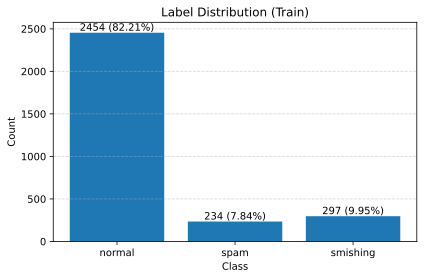

In [24]:
names = [labels_names[i] for i in [0, 1, 2]]
vals  = counts.values

plt.figure(figsize=(6, 4))
bars = plt.bar(names, vals)
plt.title("Label Distribution (Train)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.5)

for b, c in zip(bars, vals):
    pct = (c / total * 100.0) if total > 0 else 0.0
    plt.text(b.get_x() + b.get_width()/2, b.get_height(),
             f"{c} ({pct:.2f}%)",
             ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


**Steps**
1. Data clensing.
2. Feature Engineering (semantic attributes in texts)
3. N-gram 
4. Vectorization: 
   1. combining manual-engineered features and N-gram
   2. count N-gram
   3. TF-IDF n-gram only

In [64]:
import re, unicodedata, string
from urllib.parse import urlparse

URL_RE = re.compile(r"(https?://\S+|www\.\S+)", re.I)
NUM_RE = re.compile(r"\b\d+(?:[.,]\d+)?\b")            
EMAIL_RE = re.compile(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", re.I)

def extract_domain(u: str) -> str:
    try:
        if not u.lower().startswith(("http://", "https://")):
            u = "http://" + u
        host = urlparse(u).hostname or ""
    except Exception:
        host = ""
    return host.lower()

def normalize_trad(s: str) -> str:
    if not isinstance(s, str):
        s = str(s)
    s = unicodedata.normalize("NFKC", s)
    s = URL_RE.sub("__URL__", s)
    s = EMAIL_RE.sub("__EMAIL__", s)
    s = NUM_RE.sub("__NUM__", s)
    s = s.lower()
    s = re.sub(r"\s+", " ", s).strip()
    return s

train_df["text_norm"] = train_df["text"].map(normalize_trad)
valtest_txt_df["text_norm"]   = valtest_txt_df["text"].map(normalize_trad)
valtest_merged["text_norm"]  = valtest_merged["text"].map(normalize_trad)

train_df[["text", "text_norm"]].head(3)
valtest_txt_df[["text", "text_norm"]].head(3)
valtest_merged[["text", "text_norm"]].head(3)

# train_df.head()
# valtest_merged.head()

val_df = (valtest_merged.loc[valtest_merged["Usage"].str.lower()=="val"].sort_values("Id").reset_index(drop=True))
test_df = (valtest_merged.loc[valtest_merged["Usage"].str.lower()=="test"].sort_values("Id").reset_index(drop=True))

# val_df  = valtest_txt_df.loc[valtest_merged["Usage"].str.lower()=="val"].sort_values("Id").reset_index(drop=True)
# test_df = valtest_txt_df.loc[valtest_merged["Usage"].str.lower()=="test"].sort_values("Id").reset_index(drop=True)

print(train_df.shape, val_df.shape, test_df.shape)
# train_df.head(2), val_df.head(2), test_df.head(2)
test_df.head()



(2985, 3) (1493, 5) (1493, 5)


,Id,Prediction,Usage,text,text_norm
0,2,0,test,Hey i booked the kb on sat already... what oth...,hey i booked the kb on sat already... what oth...
1,4,0,test,Hmm .. Bits and pieces lol ... *sighs* ...,hmm .. bits and pieces lol ... *sighs* ...
2,6,0,test,10 min later k...,__num__ min later k...
3,8,2,test,FREE2DAY sexy St George's Day pic of Jordan!Tx...,free2day sexy st george's day pic of jordan!tx...
4,10,2,test,Your B4U voucher w/c 27/03 is MARSMS. Log onto...,your b4u voucher w/c __num__/__num__ is marsms...


In [36]:
SHORTENERS = {
    "t.co","bit.ly","goo.gl","tinyurl.com","ow.ly","buff.ly","t.ly","rebrand.ly",
    "is.gd","s.id","cutt.ly","rb.gy","trib.al","bitly.com","lnkd.in","shorturl.at",
    "zpr.io","forms.gle","youtu.be"
}
TOP_TLDS = {"com","net","org","cn","hk","uk","us","info","xyz","io"}

BRAND_WORDS = {
    "bank","paypal","apple","amazon","facebook","whatsapp","instagram","google",
    "microsoft","netflix","dhl","fedex","ocbc","dbs","hsbc","citibank","visa","mastercard"
}

EMOJI_RE = re.compile(r"[\U0001F300-\U0001FAFF\u2600-\u26FF]+", re.UNICODE)
URL_FINDER = re.compile(r"(https?://\S+|www\.\S+)", re.I)


In [37]:
def brand_in(s: str) -> bool:
    s_low = s.lower()
    return any(b in s_low for b in BRAND_WORDS)

def domain_has_brand(domain: str) -> bool:
    return any(b in domain for b in BRAND_WORDS)

def extract_features(text: str) -> dict:
    raw = str(text)

    urls = URL_FINDER.findall(raw)
    domains = [extract_domain(u) for u in urls if extract_domain(u)]
    tlds = [d.split(".")[-1] for d in domains if "." in d]

    num_urls = len(urls)
    num_domains = len(domains)
    num_short = sum(1 for d in domains if d in SHORTENERS)

    tld_com = sum(1 for t in tlds if t == "com")
    tld_cn  = sum(1 for t in tlds if t == "cn")
    tld_hk  = sum(1 for t in tlds if t == "hk")
    tld_others = sum(1 for t in tlds if t not in {"com","cn","hk"})

    brand_text = brand_in(raw)
    brand_in_domain = any(domain_has_brand(d) for d in domains)
    brand_mismatch = 1.0 if (brand_text and not brand_in_domain) else 0.0

    num_6digit_codes = len(re.findall(r"\b\d{6}\b", raw))
    phone_like = len(re.findall(r"\b\d{8,11}\b", raw))
    verify_kw = 1.0 if re.search(r"\b(otp|verify|code|verification)\b", raw, re.I) else 0.0
    money_hits = re.findall(r"(?:\$|£|€|¥|usd|hkd|sgd|gbp)\s*\d+(?:[.,]\d+)?", raw, re.I)
    has_money = 1.0 if len(money_hits) > 0 else 0.0

    punct_cnt = sum(ch in string.punctuation for ch in raw)
    exclaim_cnt = raw.count("!")
    question_cnt = raw.count("?")

    letters = [c for c in raw if c.isalpha()]
    upper_ratio = (sum(1 for c in letters if c.isupper()) / len(letters)) if letters else 0.0
    allcaps_tokens = re.findall(r"\b[A-Z]{3,}\b", raw)
    alpha_tokens   = re.findall(r"\b[A-Za-z]{3,}\b", raw)
    allcaps_ratio  = (len(allcaps_tokens) / len(alpha_tokens)) if alpha_tokens else 0.0

    emoji_cnt = len(EMOJI_RE.findall(raw))

    return {
        "num_urls": num_urls,
        "num_domains": num_domains,
        "num_short_urls": num_short,
        "tld_com": tld_com, "tld_cn": tld_cn, "tld_hk": tld_hk, "tld_others": tld_others,
        "brand_in_text": 1.0 if brand_text else 0.0,
        "brand_in_domain": 1.0 if brand_in_domain else 0.0,
        "brand_mismatch": brand_mismatch,
        "num_6digit_codes": num_6digit_codes,
        "phone_like": phone_like,
        "verify_kw": verify_kw,
        "has_money": has_money,
        "punct_cnt": float(punct_cnt),
        "exclaim_cnt": float(exclaim_cnt),
        "question_cnt": float(question_cnt),
        "upper_ratio": float(upper_ratio),
        "allcaps_ratio": float(allcaps_ratio),
        "emoji_cnt": float(emoji_cnt),
    }

def build_eng_df(series: pd.Series) -> pd.DataFrame:
    rows = [extract_features(x) for x in series.tolist()]
    df = pd.DataFrame(rows)
    return df[sorted(df.columns)]

In [45]:
eng_cols_order = sorted(extract_features("example").keys())

eng_train = build_eng_df(train_df["text"])
eng_val   = build_eng_df(val_df["text"])
eng_test  = build_eng_df(test_df["text"])

eng_test.head(3)

,allcaps_ratio,brand_in_domain,brand_in_text,brand_mismatch,emoji_cnt,exclaim_cnt,has_money,num_6digit_codes,num_domains,num_short_urls,num_urls,phone_like,punct_cnt,question_cnt,tld_cn,tld_com,tld_hk,tld_others,upper_ratio,verify_kw
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,4.0,1.0,0,0,0,0,0.018182,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,10.0,0.0,0,0,0,0,0.083333,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,0,3.0,0.0,0,0,0,0,0.000000,0.0


In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy import sparse
import pickle as pk
from pathlib import Path

ART = Path("artifacts_trad")
ART.mkdir(exist_ok=True)

# n-gram (1-2)
tfidf_word = TfidfVectorizer(
    analyzer="word",
    token_pattern=r"(?u)\b\w+\b",   #  __URL__ / __NUM__ , etc.
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

Xw_tr = tfidf_word.fit_transform(train_df["text_norm"])
Xw_va = tfidf_word.transform(val_df["text_norm"])
Xw_te = tfidf_word.transform(test_df["text_norm"])

# n-gram(3–5)
tfidf_char = TfidfVectorizer(
    analyzer="char",
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
    lowercase=False  
)

Xc_tr = tfidf_char.fit_transform(train_df["text_norm"])
Xc_va = tfidf_char.transform(val_df["text_norm"])
Xc_te = tfidf_char.transform(test_df["text_norm"])

print("word tfidf:", Xw_tr.shape, Xw_va.shape, Xw_te.shape)
print("char tfidf:", Xc_tr.shape, Xc_va.shape, Xc_te.shape)

with open(ART / "tfidf_word.pkl", "wb") as f:
    pk.dump(tfidf_word, f)
with open(ART / "tfidf_char.pkl", "wb") as f:
    pk.dump(tfidf_char, f)

word tfidf: (2985, 8585) (1493, 8585) (1493, 8585)
char tfidf: (2985, 49807) (1493, 49807) (1493, 49807)


In [48]:
from scipy.sparse import csr_matrix, hstack
from sklearn.preprocessing import StandardScaler
import numpy as np

def to_sparse_scaled(df_num: pd.DataFrame, scaler: StandardScaler=None, fit=False):
    X = csr_matrix(df_num.astype(np.float32).values)
    if scaler is None:
        scaler = StandardScaler(with_mean=False)
    X_scaled = scaler.fit_transform(X) if fit else scaler.transform(X)
    return X_scaled, scaler


In [49]:
eng_train = eng_train[eng_cols_order]
eng_val   = eng_val[eng_cols_order]
eng_test  = eng_test[eng_cols_order]

Xeng_tr, eng_scaler = to_sparse_scaled(eng_train, fit=True)
Xeng_va, _ = to_sparse_scaled(eng_val, scaler=eng_scaler, fit=False)
Xeng_te, _ = to_sparse_scaled(eng_test, scaler=eng_scaler, fit=False)

X_tr_trad = hstack([Xw_tr, Xc_tr, Xeng_tr], format="csr")
X_va_trad = hstack([Xw_va, Xc_va, Xeng_va], format="csr")
X_te_trad = hstack([Xw_te, Xc_te, Xeng_te], format="csr")

y_train = train_df['label'].to_numpy(np.int64)
print(f"Final train/val/test shapes: {X_tr_trad.shape}, {X_va_trad.shape}, {X_te_trad.shape}")

Final train/val/test shapes: (2985, 58412), (1493, 58412), (1493, 58412)


In [52]:
eng_train.describe().T.assign(is_constant=lambda x: x["std"]==0).head(12)

,count,mean,std,min,25%,50%,75%,max,is_constant
allcaps_ratio,2985.0,0.039033,0.143505,0.0,0.0,0.0,0.0,1.0,False
brand_in_domain,2985.0,0.001005,0.031692,0.0,0.0,0.0,0.0,1.0,False
brand_in_text,2985.0,0.012395,0.110661,0.0,0.0,0.0,0.0,1.0,False
brand_mismatch,2985.0,0.011390,0.106133,0.0,0.0,0.0,0.0,1.0,False
emoji_cnt,2985.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,True
exclaim_cnt,2985.0,0.260637,0.732990,0.0,0.0,0.0,0.0,11.0,False
has_money,2985.0,0.046231,0.210021,0.0,0.0,0.0,0.0,1.0,False
num_6digit_codes,2985.0,0.002345,0.048377,0.0,0.0,0.0,0.0,1.0,False
num_domains,2985.0,0.031156,0.173768,0.0,0.0,0.0,0.0,1.0,False
num_short_urls,2985.0,0.000670,0.025880,0.0,0.0,0.0,0.0,1.0,False


## Methodology and Experimental Setup

### Task and Metric
- This task is a tri-classification task, where label 0 represents normal, 1 represents spam, and 2 represents smishing.
- Because the classes are imbalanced as illustrated above, we use Macro-F1 for model selection.
- Additionally, we report the Accuracy score and the confusion matrix.
### Chosen Models
1. Generative Models
   1. Gaussian Naive bayes (GNB)
   2. Linear Discriminant Analysis (LDA)
   3. Quadratic Discriminant Analysis (QDA)
2. Discriminative Models
   1. Logistic Regression (LR)
   2. Linear SVM
   3. Kernel SVM
3. Others
   1. Decision Tree
   2. Random Forest
   3. MLP

In [69]:
import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

def evaluate_model(model, name, X_train, y_train, X_val=None, y_val=None):
    model.fit(X_train, y_train)

    # Train
    y_tr = model.predict(X_train)
    acc_tr = accuracy_score(y_train, y_tr)
    f1_tr  = f1_score(y_train, y_tr, average='macro')

    out = {
        "model": name,
        "train_acc": acc_tr,
        "train_macro_f1": f1_tr,
        "val_acc": None,
        "val_macro_f1": None,
        "val_cm": None,
        "val_pred": None,
        "estimator": model
    }

    print(f"\n===== {name} =====")
    print(f"Train Acc: {acc_tr:.4f} | Macro-F1: {f1_tr:.4f}")

    if X_val is not None:
        y_va = model.predict(X_val)
        out["val_pred"] = y_va
        if y_val is not None:
            acc_va = accuracy_score(y_val, y_va)
            f1_va  = f1_score(y_val, y_va, average='macro')
            cm_va  = confusion_matrix(y_val, y_va)
            out.update({"val_acc": acc_va, "val_macro_f1": f1_va, "val_cm": cm_va})
            print(f"Valid Acc: {acc_va:.4f} | Macro-F1: {f1_va:.4f}")
            print("Valid Confusion Matrix (rows=true, cols=pred):\n", cm_va)
        else:
            print("Valid: no labels provided (predictions only).")
    return out

In [70]:
train_texts = train_df["text_norm"].astype(str).values
train_labels = train_df["label"].astype(np.int64).values
val_texts = val_df["text_norm"].astype(str).values
val_labels = val_df["Prediction"].astype(np.int64).values

In [71]:
## Generative
### GNB Count n-gram
gnb_count = Pipeline([
    ("count", CountVectorizer(max_features=50000, ngram_range=(1,2))),
    ("todense", FunctionTransformer(lambda X: X.toarray(), accept_sparse=True)),
    ("clf", GaussianNB(var_smoothing=1e-8))
])

### GNB TF-IDF SVD
gnb_tfidf_svd = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("svd",   TruncatedSVD(n_components=200, random_state=SEED)),
    ("scale", StandardScaler(with_mean=True)),
    ("clf",   GaussianNB(var_smoothing=1e-8))
])

### LDA TF-IDF SVD
lda_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("svd",   TruncatedSVD(n_components=200, random_state=SEED)),
    ("scale", StandardScaler(with_mean=True)),
    ("clf",   LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
])

### QDA TF-IDF SVD
qda_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("svd",   TruncatedSVD(n_components=200, random_state=SEED)),
    ("scale", StandardScaler(with_mean=True)),
    ("clf",   QuadraticDiscriminantAnalysis(reg_param=0.1))
])

## Discriminative
### LR
lr_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("scale", StandardScaler(with_mean=False)),
    ("clf",   LogisticRegression(C=1.0, penalty="l2", solver="liblinear",
                                 class_weight="balanced", max_iter=200, random_state=SEED))
])

### Linear SVM
linear_svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("scale", StandardScaler(with_mean=False)),
    ("clf",   LinearSVC(C=1.0, class_weight="balanced", random_state=SEED))
])

### Kernel SVM
rbf_svm_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1,2))),
    ("scale", StandardScaler(with_mean=False)),
    ("clf",   SVC(kernel="rbf", C=10.0, gamma=1e-4, class_weight="balanced", random_state=SEED))
])

## Others
### Decision Tree
dt_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1,2))),
    ("clf",   DecisionTreeClassifier(max_depth=16, min_samples_leaf=5, random_state=SEED))
])

### Random Forest
rf_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=30000, ngram_range=(1,2))),
    ("clf",   RandomForestClassifier(n_estimators=400, max_depth=None, n_jobs=-1, random_state=SEED))
])

### MLP
mlp_pipe = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1,2))),
    ("svd",   TruncatedSVD(n_components=200, random_state=SEED)),
    ("scale", StandardScaler(with_mean=True)),
    ("clf",   MLPClassifier(hidden_layer_sizes=(256, 128), activation="relu",
                            alpha=1e-4, learning_rate_init=1e-3,
                            batch_size=64, max_iter=50, early_stopping=True,
                            random_state=SEED))
])

In [72]:
models = [
    ("GNB (Count)", gnb_count),
    ("GNB (TF-IDF+SVD)", gnb_tfidf_svd),
    ("LDA", lda_pipe),
    ("QDA", qda_pipe),
    ("LR", lr_pipe),
    ("Linear SVM", linear_svm_pipe),
    ("Kernel SVM", rbf_svm_pipe),
    ("Decision Tree", dt_pipe),
    ("Random Forest", rf_pipe),
    ("MLP", mlp_pipe),
]

results = []
for name, pipe in models:
    res = evaluate_model(pipe, name, train_texts, train_labels, val_texts, val_labels)
    results.append({
        "model": name,
        "train_acc": res["train_acc"],
        "train_macro_f1": res["train_macro_f1"],
        "val_acc": res["val_acc"],
        "val_macro_f1": res["val_macro_f1"]
    })
    if res["val_pred"] is not None:
        col = "Pred_" + name.replace(" ", "_").replace("(", "").replace(")", "")
        try:
            val_df[col] = res["val_pred"]
        except Exception:
            pass

summary_df = pd.DataFrame(results)
summary_df.sort_values(by=["val_macro_f1", "val_acc"], ascending=False, inplace=True)
summary_df


===== GNB (Count) =====
Train Acc: 0.9926 | Macro-F1: 0.9774
Valid Acc: 0.9203 | Macro-F1: 0.7997
Valid Confusion Matrix (rows=true, cols=pred):
 [[1155   22   22]
 [  34   73   19]
 [   4   18  146]]

===== GNB (TF-IDF+SVD) =====
Train Acc: 0.8379 | Macro-F1: 0.6587
Valid Acc: 0.8540 | Macro-F1: 0.6827
Valid Confusion Matrix (rows=true, cols=pred):
 [[1100   15   84]
 [  42   74   10]
 [  17   50  101]]

===== LDA =====
Train Acc: 0.9514 | Macro-F1: 0.8588
Valid Acc: 0.9451 | Macro-F1: 0.8497
Valid Confusion Matrix (rows=true, cols=pred):
 [[1187   11    1]
 [  23   92   11]
 [  10   26  132]]

===== QDA =====
Train Acc: 0.9518 | Macro-F1: 0.8964
Valid Acc: 0.9243 | Macro-F1: 0.8285
Valid Confusion Matrix (rows=true, cols=pred):
 [[1143   55    1]
 [  18  100    8]
 [   2   29  137]]


/opt/anaconda3/envs/cityu_cs_courses/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1296: FutureWarning: Using the 'liblinear' solver for multiclass classification is deprecated. An error will be raised in 1.8. Either use another solver which supports the multinomial loss or wrap the estimator in a OneVsRestClassifier to keep applying a one-versus-rest scheme.
  warnings.warn(



===== LR =====
Train Acc: 0.9970 | Macro-F1: 0.9886
Valid Acc: 0.9411 | Macro-F1: 0.8281
Valid Confusion Matrix (rows=true, cols=pred):
 [[1198    0    1]
 [  51   63   12]
 [  11   13  144]]


/opt/anaconda3/envs/cityu_cs_courses/lib/python3.12/site-packages/sklearn/svm/_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



===== Linear SVM =====
Train Acc: 0.9970 | Macro-F1: 0.9886
Valid Acc: 0.9377 | Macro-F1: 0.8212
Valid Confusion Matrix (rows=true, cols=pred):
 [[1199    0    0]
 [  57   60    9]
 [  15   12  141]]

===== Kernel SVM =====
Train Acc: 0.9970 | Macro-F1: 0.9886
Valid Acc: 0.8801 | Macro-F1: 0.6287
Valid Confusion Matrix (rows=true, cols=pred):
 [[1199    0    0]
 [ 105   17    4]
 [  62    8   98]]

===== Decision Tree =====
Train Acc: 0.9575 | Macro-F1: 0.8767
Valid Acc: 0.9196 | Macro-F1: 0.7617
Valid Confusion Matrix (rows=true, cols=pred):
 [[1184   12    3]
 [  40   56   30]
 [  12   23  133]]

===== Random Forest =====
Train Acc: 0.9970 | Macro-F1: 0.9885
Valid Acc: 0.9357 | Macro-F1: 0.8204
Valid Confusion Matrix (rows=true, cols=pred):
 [[1199    0    0]
 [  56   63    7]
 [  19   14  135]]

===== MLP =====
Train Acc: 0.9722 | Macro-F1: 0.9129
Valid Acc: 0.9538 | Macro-F1: 0.8691
Valid Confusion Matrix (rows=true, cols=pred):
 [[1189    7    3]
 [  19   93   14]
 [   5   21  14

,model,train_acc,train_macro_f1,val_acc,val_macro_f1
9,MLP,0.972194,0.912864,0.953784,0.869147
2,LDA,0.951424,0.858776,0.945077,0.849707
3,QDA,0.951759,0.896432,0.924313,0.828532
4,LR,0.996985,0.988582,0.941058,0.828099
5,Linear SVM,0.996985,0.988564,0.937709,0.821234
8,Random Forest,0.996985,0.988544,0.935700,0.820443
0,GNB (Count),0.992630,0.977411,0.920295,0.799711
7,Decision Tree,0.957454,0.876669,0.919625,0.761674
1,GNB (TF-IDF+SVD),0.837856,0.658692,0.853985,0.682653
6,Kernel SVM,0.996985,0.988582,0.880107,0.628661
